## Tarea 5: Regularización — Soluciones (parte práctica)

Soluciones de los ejercicios de Python de la tarea de práctica. La numeración corresponde a la versión actual de `Tareas/Tarea5.ipynb`. Úsalas para verificar tu trabajo (o el de tu agente) **después** de intentarlo.

Protocolo experimental usado en todo el notebook: semilla fija (`seed=1234`), el **mismo** split train/val (90/10) en todos los experimentos, **un solo factor variado a la vez**, y para cada ejercicio: curvas + tabla resumen + interpretación.

### Ejercicio 1: Weight decay (L2) y optimizadores

**Setup.** MNIST (clasificación), MLP superficial `28×28 → 512 → 10` **sin** BatchNorm, `epochs=30`, `batch_size=128`, `seed=1234`.

**Experimentos.** Para cada optimizador en {SGD, SGD+momentum(0.9), Adam} entrenamos 3 corridas con `weight_decay ∈ {0, 1e-4, 1e-3}`, manteniendo el `lr` **fijo por optimizador**. Registramos por época: `train_loss`, `val_loss`, `train_acc`, `val_acc` y `param_norm = ||θ||₂`.

**Sobre el `lr` "ajustado por optimizador".** El enunciado dice `lr=1e-2 (ajustar por optimizador)`. Usamos:

| optimizador | lr |
|---|---|
| SGD | `1e-2` |
| SGD + momentum(0.9) | `1e-2` |
| Adam | `1e-3` |

La razón: SGD y SGD+momentum actualizan con el gradiente crudo, así que necesitan un paso relativamente grande; Adam normaliza el gradiente por una estimación de su segundo momento, de modo que el tamaño efectivo del paso es ≈ `lr` **por parámetro**. Con `lr=1e-2` Adam da pasos enormes y se vuelve inestable en esta red; `1e-3` es su valor por defecto y el punto de comparación justo. Lo importante para el experimento es que el `lr` **no cambia dentro de un optimizador**, así el único factor que varía entre las tres curvas de una figura es el `weight_decay`.

**Nota sobre `weight_decay` en PyTorch.** Tanto `optim.SGD` como `optim.Adam` implementan weight decay como una penalización L2 *sumada al gradiente* (`g ← g + wd·θ`), **no** como el "decoupled weight decay" de `AdamW`. Esta distinción es justamente lo que hace que weight decay y Adam interactúen de forma no trivial, y es parte de lo que el ejercicio pide observar.

In [1]:
# ============================================================================
# Configuración común a los tres ejercicios
# ============================================================================
import os
# Workaround de macOS: varias copias de libomp (numpy/torch) en el mismo proceso.
# Debe ir ANTES de importar torch.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import copy, math, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

SEED = 1234


def set_seed(seed: int = SEED) -> None:
    """Fija las semillas de random / numpy / torch.

    Llamamos a esta función ANTES de construir cada modelo y cada DataLoader,
    para que todas las corridas que comparamos arranquen exactamente de la
    misma inicialización y vean los minibatches en el mismo orden. Así, la
    única diferencia entre dos corridas es el factor que estamos variando
    (weight_decay, lambda de L1, augmentation, ...).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)          # cubre CPU y MPS
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# GPU de Apple (Metal Performance Shaders) si está disponible; si no, CPU.
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)

# MNIST ya descargado en el repo (Notebooks/data). La ruta es relativa a Soluciones/.
DATA_ROOT = "../Notebooks/data"
MEAN, STD = 0.1307, 0.3081          # estadísticas estándar de MNIST

torch: 2.11.0 | device: mps


In [2]:
# ============================================================================
# Datos: MNIST con un split train/val 90/10 FIJO
# ============================================================================
# Para los ejercicios 1 y 2 no necesitamos augmentation, así que en vez de
# pasar por PIL en cada época pre-normalizamos TODO el dataset una sola vez y
# lo dejamos residente en la GPU. La transformación
#       x = (pixel/255 - 0.1307) / 0.3081
# es EXACTAMENTE la misma que aplica transforms.Compose([ToTensor(), Normalize()]),
# solo que vectorizada. Esto reduce el tiempo por época de ~4 s a ~0.4 s, lo que
# hace viable correr las 9 combinaciones del ejercicio 1.

def mnist_tensor_splits(seed: int = SEED):
    """Devuelve (train_ds, val_ds, idx_train, idx_val) con split 90/10 fijo."""
    raw = datasets.MNIST(root=DATA_ROOT, train=True, download=True)

    X = ((raw.data.float() / 255.0) - MEAN) / STD     # (60000, 28, 28)
    y = raw.targets.clone()                           # (60000,)

    # Permutación reproducible: mismo split en TODOS los experimentos.
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(X), generator=g)
    n_val = int(0.10 * len(X))
    idx_val, idx_train = perm[:n_val], perm[n_val:]

    train_ds = TensorDataset(X[idx_train].to(device), y[idx_train].to(device))
    val_ds   = TensorDataset(X[idx_val].to(device),   y[idx_val].to(device))
    return train_ds, val_ds, idx_train, idx_val


train_ds, val_ds, IDX_TRAIN, IDX_VAL = mnist_tensor_splits()
print(f"train: {len(train_ds)} ejemplos | val: {len(val_ds)} ejemplos")
print("media/std del train normalizado: "
      f"{train_ds.tensors[0].mean():.4f} / {train_ds.tensors[0].std():.4f}")


def make_loaders(batch_size: int, seed: int = SEED):
    """DataLoaders de train (shuffle reproducible) y val (sin shuffle)."""
    g = torch.Generator().manual_seed(seed)
    tl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    vl = DataLoader(val_ds, batch_size=1024, shuffle=False)
    return tl, vl

train: 54000 ejemplos | val: 6000 ejemplos


media/std del train normalizado: 0.0001 / 1.0002


In [3]:
# ============================================================================
# Modelo y utilidades de entrenamiento / medición
# ============================================================================
class MLP(nn.Module):
    """MLP totalmente conectada, SIN BatchNorm y SIN dropout.

    hidden=(512,)      -> 784 -> 512 -> 10          (ejercicios 1 y 3)
    hidden=(256, 128)  -> 784 -> 256 -> 128 -> 10   (ejercicio 2)
    """

    def __init__(self, hidden=(512,), in_dim=28 * 28, n_classes=10):
        super().__init__()
        layers, d = [nn.Flatten()], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers.append(nn.Linear(d, n_classes))   # capa de salida: logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def param_norm(model):
    """||θ||₂ sobre TODOS los parámetros (pesos y sesgos) concatenados."""
    with torch.no_grad():
        sq = sum((p.detach() ** 2).sum() for p in model.parameters())
        return float(torch.sqrt(sq).item())


def l1_penalty(model):
    """Σ|w| sobre las MATRICES de pesos (excluye sesgos, como es convención)."""
    return sum(p.abs().sum() for n, p in model.named_parameters()
               if n.endswith("weight"))


def train_one_epoch(model, loader, optimizer, criterion, l1_lambda=0.0):
    """Una pasada por el train set. Devuelve (loss de datos media, accuracy).

    OJO: si l1_lambda > 0, la penalización se suma al loss que se deriva, pero
    lo que reportamos es solo el término de datos (cross-entropy). Así las
    curvas de distintos lambda son comparables entre sí.
    """
    model.train()
    tot_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        ce = criterion(logits, yb)
        loss = ce + l1_lambda * l1_penalty(model) if l1_lambda > 0 else ce
        loss.backward()
        optimizer.step()

        tot_loss += ce.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return tot_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluación sin gradientes. Devuelve (loss media, accuracy)."""
    model.eval()
    tot_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        tot_loss += criterion(logits, yb).item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return tot_loss / n, correct / n


@torch.no_grad()
def expected_calibration_error(model, loader, n_bins=15):
    """ECE con binning uniforme sobre la confianza (max softmax).

    ECE = Σ_b (|B_b|/N) · | acc(B_b) − conf(B_b) |

    Interpretación: mide cuánto se despega la confianza del modelo de su
    accuracy real. ECE=0 -> perfectamente calibrado; un modelo sobreajustado
    típicamente predice con confianza ~1.0 y falla más seguido de lo que su
    confianza sugiere, lo que infla el ECE.
    """
    model.eval()
    confs, hits = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = F.softmax(model(xb), dim=1)
        conf, pred = probs.max(dim=1)
        confs.append(conf.cpu())
        hits.append((pred == yb).float().cpu())
    confs = torch.cat(confs)
    hits = torch.cat(hits)

    edges = torch.linspace(0.0, 1.0, n_bins + 1)
    N, ece = confs.numel(), 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        mask = (confs > lo) & (confs <= hi) if i > 0 else (confs >= lo) & (confs <= hi)
        if mask.sum() > 0:
            w = mask.float().sum().item() / N
            ece += w * abs(hits[mask].mean().item() - confs[mask].mean().item())
    return ece


def fit(model, train_loader, val_loader, optimizer, epochs,
        l1_lambda=0.0, tag="", log_every=10):
    """Bucle de entrenamiento. Devuelve el history con las 5 series pedidas."""
    criterion = nn.CrossEntropyLoss()
    hist = defaultdict(list)
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, l1_lambda)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        pn = param_norm(model)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)
        hist["param_norm"].append(pn)

        if log_every and (ep == 1 or ep % log_every == 0 or ep == epochs):
            print(f"   [{tag}] ep {ep:3d}/{epochs} | train {tr_loss:.4f}/{tr_acc:.4f}"
                  f" | val {va_loss:.4f}/{va_acc:.4f} | ||θ||={pn:7.2f}")
    print(f"   [{tag}] listo en {time.time() - t0:.1f}s")
    return dict(hist)


print("Parámetros MLP 784-512-10  :", f"{count_parameters(MLP((512,))):,}")
print("Parámetros MLP 784-256-128-10:", f"{count_parameters(MLP((256, 128))):,}")

Parámetros MLP 784-512-10  : 407,050
Parámetros MLP 784-256-128-10: 235,146


In [4]:
# ============================================================================
# EJERCICIO 1 — 3 optimizadores x 3 weight_decay = 9 corridas
# ============================================================================
EPOCHS_1, BATCH_1 = 30, 128
WDS = [0.0, 1e-4, 1e-3]

# lr fijo por optimizador (ver justificación en la celda de texto de arriba)
OPTIMIZERS = {
    "SGD":          dict(lr=1e-2,
                         build=lambda p, lr, wd: optim.SGD(p, lr=lr, weight_decay=wd)),
    "SGD+momentum": dict(lr=1e-2,
                         build=lambda p, lr, wd: optim.SGD(p, lr=lr, momentum=0.9,
                                                           weight_decay=wd)),
    "Adam":         dict(lr=1e-3,
                         build=lambda p, lr, wd: optim.Adam(p, lr=lr, weight_decay=wd)),
}

res1 = {}          # (optimizador, wd) -> dict con history y métricas finales

for oname, ocfg in OPTIMIZERS.items():
    for wd in WDS:
        tag = f"{oname} wd={wd:g}"
        print(f"\n=== {tag} (lr={ocfg['lr']:g}) ===")

        set_seed(SEED)                                   # misma init y mismo orden de batches
        model = MLP(hidden=(512,)).to(device)
        tl, vl = make_loaders(BATCH_1)
        opt = ocfg["build"](model.parameters(), ocfg["lr"], wd)

        hist = fit(model, tl, vl, opt, EPOCHS_1, tag=tag)

        res1[(oname, wd)] = dict(
            hist=hist,
            lr=ocfg["lr"],
            val_acc=hist["val_acc"][-1],
            train_acc=hist["train_acc"][-1],
            val_loss=hist["val_loss"][-1],
            param_norm=hist["param_norm"][-1],
            ece=expected_calibration_error(model, vl, n_bins=15),
        )

print("\nCorridas completadas:", len(res1))


=== SGD wd=0 (lr=0.01) ===


   [SGD wd=0] ep   1/30 | train 0.7792/0.8191 | val 0.4169/0.8928 | ||θ||=  13.47


   [SGD wd=0] ep  10/30 | train 0.1832/0.9484 | val 0.1890/0.9492 | ||θ||=  14.04


   [SGD wd=0] ep  20/30 | train 0.1155/0.9686 | val 0.1314/0.9630 | ||θ||=  14.48


   [SGD wd=0] ep  30/30 | train 0.0834/0.9782 | val 0.1065/0.9690 | ||θ||=  14.85
   [SGD wd=0] listo en 21.2s


...

   [Adam wd=0.0001] ep  30/30 | train 0.0097/0.9968 | val 0.0883/0.9758 | ||θ||=  23.39
   [Adam wd=0.0001] listo en 25.7s

=== Adam wd=0.001 (lr=0.001) ===


   [Adam wd=0.001] ep   1/30 | train 0.2507/0.9264 | val 0.1369/0.9597 | ||θ||=  12.04


   [Adam wd=0.001] ep  10/30 | train 0.0536/0.9840 | val 0.0799/0.9775 | ||θ||=  11.88


   [Adam wd=0.001] ep  20/30 | train 0.0432/0.9872 | val 0.0733/0.9763 | ||θ||=  11.48


   [Adam wd=0.001] ep  30/30 | train 0.0397/0.9884 | val 0.0726/0.9760 | ||θ||=  11.30
   [Adam wd=0.001] listo en 25.3s

Corridas completadas: 9


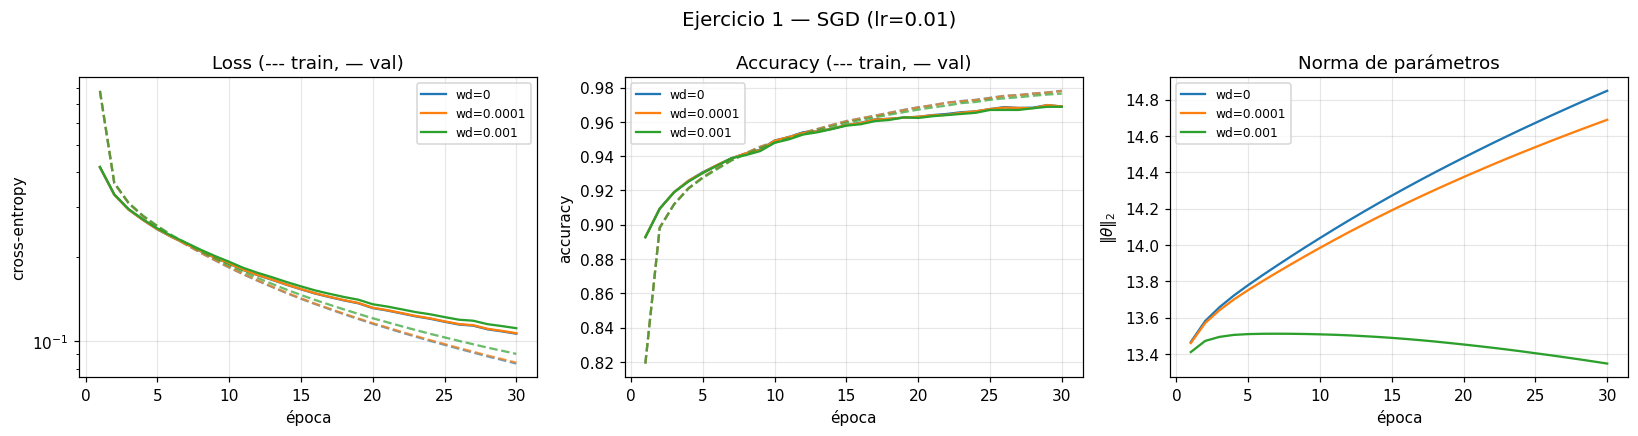

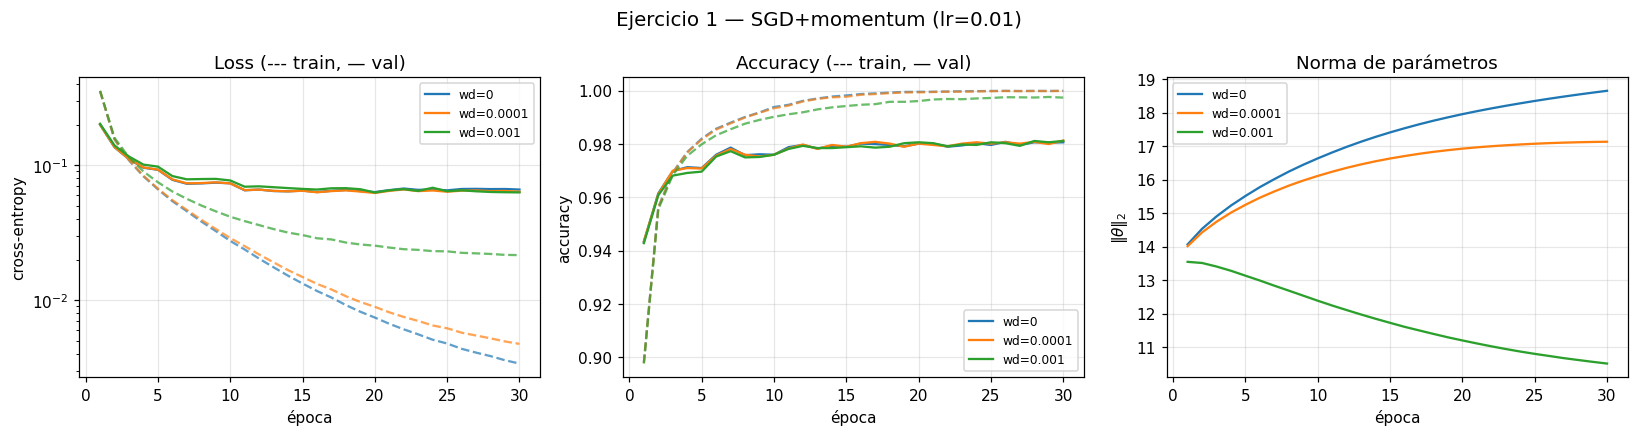

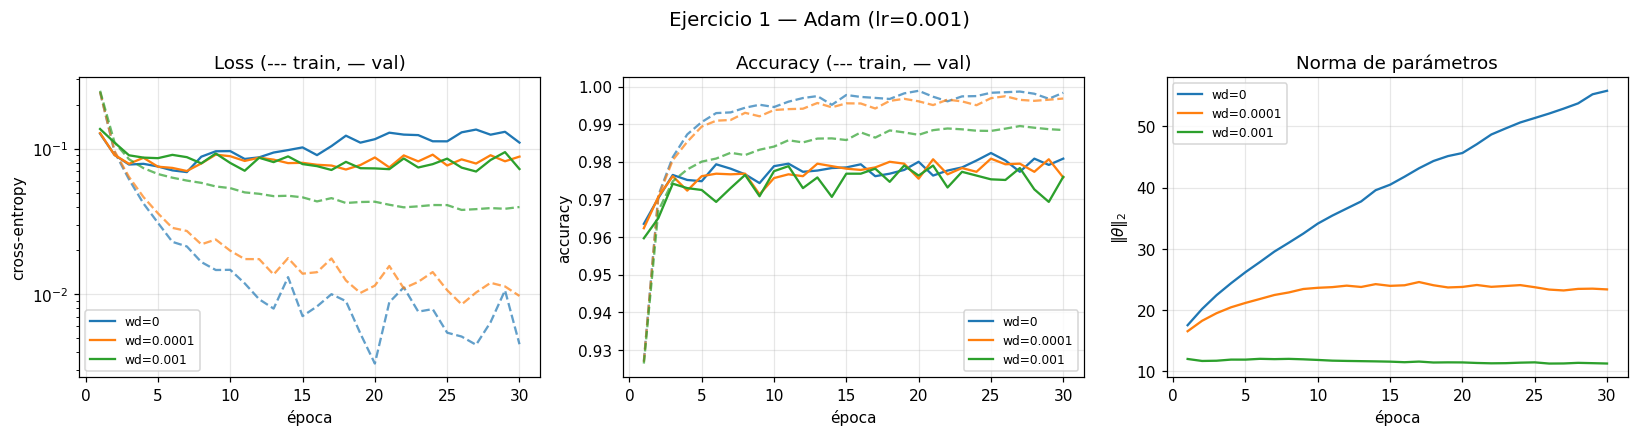

In [5]:
# ----------------------------------------------------------------------------
# Una figura por optimizador, con las tres curvas de weight_decay
# ----------------------------------------------------------------------------
colors = {0.0: "tab:blue", 1e-4: "tab:orange", 1e-3: "tab:green"}

for oname, ocfg in OPTIMIZERS.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ep = range(1, EPOCHS_1 + 1)

    for wd in WDS:
        h = res1[(oname, wd)]["hist"]
        c = colors[wd]
        axes[0].plot(ep, h["train_loss"], color=c, ls="--", alpha=.7)
        axes[0].plot(ep, h["val_loss"],   color=c, ls="-",  label=f"wd={wd:g}")
        axes[1].plot(ep, h["train_acc"],  color=c, ls="--", alpha=.7)
        axes[1].plot(ep, h["val_acc"],    color=c, ls="-",  label=f"wd={wd:g}")
        axes[2].plot(ep, h["param_norm"], color=c, ls="-",  label=f"wd={wd:g}")

    axes[0].set(xlabel="época", ylabel="cross-entropy", yscale="log",
                title="Loss (--- train, — val)")
    axes[1].set(xlabel="época", ylabel="accuracy", title="Accuracy (--- train, — val)")
    axes[2].set(xlabel="época", ylabel=r"$\|\theta\|_2$", title=r"Norma de parámetros")
    for a in axes:
        a.legend(fontsize=8)
        a.grid(alpha=.3)
    fig.suptitle(f"Ejercicio 1 — {oname} (lr={ocfg['lr']:g})", fontsize=13)
    fig.tight_layout()
    plt.show()

In [6]:
# ----------------------------------------------------------------------------
# Tabla final: val_acc, param_norm y ECE para las 9 combinaciones
# ----------------------------------------------------------------------------
rows = []
for (oname, wd), r in res1.items():
    rows.append({
        "optimizador": oname,
        "lr": r["lr"],
        "weight_decay": wd,
        "train_acc": round(r["train_acc"], 4),
        "val_acc": round(r["val_acc"], 4),
        "gap": round(r["train_acc"] - r["val_acc"], 4),
        "val_loss": round(r["val_loss"], 4),
        "param_norm": round(r["param_norm"], 2),
        "ECE(15 bins)": round(r["ece"], 4),
    })

tabla1 = pd.DataFrame(rows).sort_values(["optimizador", "weight_decay"]).reset_index(drop=True)
display(tabla1)

best = tabla1.loc[tabla1["val_acc"].idxmax()]
print(f"\nMejor val_acc: {best['optimizador']} con wd={best['weight_decay']:g} "
      f"-> val_acc={best['val_acc']:.4f}, ||θ||={best['param_norm']:.2f}, "
      f"ECE={best['ECE(15 bins)']:.4f}")
best_ece = tabla1.loc[tabla1["ECE(15 bins)"].idxmin()]
print(f"Mejor ECE   : {best_ece['optimizador']} con wd={best_ece['weight_decay']:g} "
      f"-> ECE={best_ece['ECE(15 bins)']:.4f} (val_acc={best_ece['val_acc']:.4f})")

,optimizador,lr,weight_decay,train_acc,val_acc,gap,val_loss,param_norm,ECE(15 bins)
0,Adam,0.001,0.0000,0.9984,0.9808,0.0175,0.1103,55.79,0.0138
1,Adam,0.001,0.0001,0.9968,0.9758,0.0210,0.0883,23.39,0.0113
2,Adam,0.001,0.0010,0.9884,0.9760,0.0124,0.0726,11.30,0.0063
3,SGD,0.010,0.0000,0.9782,0.9690,0.0092,0.1065,14.85,0.0134
4,SGD,0.010,0.0001,0.9780,0.9690,0.0090,0.1069,14.69,0.0135
5,SGD,0.010,0.0010,0.9765,0.9688,0.0077,0.1114,13.35,0.0171
6,SGD+momentum,0.010,0.0000,1.0000,0.9807,0.0193,0.0660,18.65,0.0068
7,SGD+momentum,0.010,0.0001,0.9999,0.9813,0.0186,0.0636,17.13,0.0056
8,SGD+momentum,0.010,0.0010,0.9974,0.9812,0.0163,0.0629,10.51,0.0072



Mejor val_acc: SGD+momentum con wd=0.0001 -> val_acc=0.9813, ||θ||=17.13, ECE=0.0056
Mejor ECE   : SGD+momentum con wd=0.0001 -> ECE=0.0056 (val_acc=0.9813)


**Interpretación:**

**a) ¿Cómo cambia la trayectoria de optimización con weight decay?** Weight decay agrega `wd·θ` al gradiente, o sea una fuerza que apunta siempre hacia el origen y cuya magnitud crece con `‖θ‖`. Esto se ve directamente en la tercera gráfica de cada figura, la de `‖θ‖₂`, y el cambio es **cualitativo**, no solo de escala:

- Con `wd=0` la norma crece de forma monótona durante las 30 épocas (SGD+momentum: `14.07 → 18.65`; Adam: `17.55 → 55.79`). Nada frena el crecimiento: para bajar la cross-entropy conviene aumentar la magnitud de los logits, y la forma barata de hacerlo es agrandar los pesos.
- Con `wd=1e-3` la trayectoria **cambia de signo**: en SGD+momentum la norma sube al principio (`13.54` en la época 1) y después *baja* hasta `10.51`. Se llega a un equilibrio entre el gradiente de datos, que quiere agrandar los pesos, y el término de decay, que quiere encogerlos.

**b) ¿Interacciona con el optimizador? Sí, y muchísimo.** Los tres regímenes de la tabla son claramente distintos:

- **SGD puro (lr=1e-2): el weight decay es casi irrelevante.** `val_acc = 0.9690 / 0.9690 / 0.9688` para `wd = 0 / 1e-4 / 1e-3`, y la norma apenas se mueve (`14.85 → 14.69 → 13.35`). La razón no es que el weight decay "no funcione": es que **no hay nada que regularizar**. En 30 épocas SGD sin momentum solo llega a `train_acc = 0.9782` con un gap de `0.0092`; el modelo todavía está *subajustado*, así que agregar un regularizador solo puede empeorar las cosas (y de hecho `wd=1e-3` es la peor de las tres, por poco).
- **SGD+momentum (lr=1e-2): el weight decay ayuda, poco pero de forma consistente.** Aquí sí hay sobreajuste (`train_acc = 1.0000` con `wd=0`), y el efecto aparece: `val_acc` pasa de `0.9807` a `0.9813` con `wd=1e-4`, y el ECE mejora de `0.0068` a `0.0056` (−18%). Con `wd=1e-3` la norma cae 44% (`18.65 → 10.51`) y aun así se conserva casi toda la accuracy (`0.9812`) con la mejor `val_loss` de la tabla (`0.0629`). Es la configuración ganadora en accuracy **y** en calibración: `SGD+momentum, wd=1e-4 → val_acc = 0.9813, ECE = 0.0056`.
- **Adam (lr=1e-3): es donde el weight decay hace la diferencia más grande.** Sin weight decay, Adam infla la norma hasta `55.79`, **tres veces** la de SGD+momentum, y produce el patrón clásico de sobreajuste *de confianza*: la `val_loss` tiene forma de U (`0.0964` en la época 10 → `0.1103` en la 30) **mientras la `val_acc` sigue subiendo** (`0.9788 → 0.9808`). Es decir, el modelo acierta igual o más, pero se equivoca con más seguridad — y eso es exactamente lo que mide el ECE: `0.0138`, el peor de las nueve corridas. Con `wd=1e-3` la norma se contiene en `11.30`, la `val_loss` baja monótonamente hasta `0.0726` y el **ECE cae a `0.0063` (−54%)**, al costo de `0.5 pp` de accuracy (`0.9808 → 0.9760`).

**c) ¿Por qué el mismo `wd` pega tan distinto en Adam que en SGD?** Porque en PyTorch `weight_decay` se implementa sumando `wd·θ` **al gradiente**, y Adam después divide ese gradiente por `√v̂` (la raíz del segundo momento estimado). Para un parámetro con gradiente de datos pequeño, `√v̂` también es pequeño, así que el término `wd·θ` sale **amplificado**: el mismo `wd=1e-3` encoge mucho más agresivamente bajo Adam que bajo SGD, y de forma desigual entre parámetros. Ese acoplamiento es justamente lo que motivó `AdamW`, que aplica el decay *después* de la normalización adaptativa (decoupled), de modo que el encogimiento sea uniforme y el `wd` se pueda ajustar independientemente del `lr`.

**d) Lo que hay que llevarse.** (i) El weight decay solo sirve si el modelo está sobreajustando: compara la fila de SGD puro con la de SGD+momentum. (ii) `val_acc` y `ECE` **no** miden lo mismo — mira Adam, donde subir `wd` empeora la accuracy y mejora la calibración a la vez. Si el modelo va a alimentar una decisión de política pública donde importa *cuánta* confianza reportar (y no solo cuál es la clase modal), el ECE puede ser el criterio correcto. (iii) La norma `‖θ‖₂` es un diagnóstico barato: si crece sin parar, el modelo está comprando confianza a cambio de generalización.

### Ejercicio 2: L1, sparsity y pruning

**Setup.** MNIST, MLP profunda con dos capas intermedias `784 → 256 → 128 → 10`, `epochs=30`, `batch_size=64`.

**Optimizador elegido (declarado):** **SGD + momentum(0.9) con `lr=1e-2`**. Lo elegimos sobre Adam a propósito: la penalización L1 induce sparsity porque agrega al gradiente un término constante `λ·sign(w)` que empuja cada peso hacia cero a velocidad fija (una especie de soft-thresholding implícito). Adam **divide** cada gradiente por su segundo momento, de modo que ese empuje constante se reescala por parámetro y el efecto de sparsificación se diluye. Con SGD el mecanismo se ve limpio, que es lo que queremos observar aquí.

**Experimentos.**
1. L1 manual: sumamos `λ · Σ|w|` al loss (solo sobre matrices de pesos, no sesgos) para `λ ∈ {0, 1e-5, 1e-4, 1e-3}`.
2. Pruning: tomamos el baseline (`λ=0`) y aplicamos `torch.nn.utils.prune.l1_unstructured(module, 'weight', amount=p)` a cada capa lineal, para `p ∈ {0.3, 0.5, 0.8}`. Evaluamos **inmediatamente** y **después de 10 épocas de fine-tuning** con `lr=1e-3` (las máscaras se mantienen durante el fine-tuning, así que los pesos podados siguen en cero).

**Nota sobre "porcentaje de ceros".** L1 con gradiente descendente casi nunca produce ceros *exactos* en punto flotante: produce pesos numéricamente diminutos. Por eso reportamos dos cosas: ceros exactos (`w == 0`, que es lo que produce el pruning) y ceros "efectivos" (`|w| ≤ 1e-3`, que es lo que produce L1).

In [7]:
# ============================================================================
# EJERCICIO 2, parte A — L1 manual para varios lambda
# ============================================================================
EPOCHS_2, BATCH_2, LR_2 = 30, 64, 1e-2
LAMBDAS = [0.0, 1e-5, 1e-4, 1e-3]


def layer_weight_stats(model, thr=1e-3):
    """Por capa lineal: nº de pesos, % de ceros exactos y % de |w| <= thr."""
    out = {}
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            w = mod.weight.detach()
            out[name] = dict(
                n=w.numel(),
                zeros_exactos=float((w == 0).float().mean().item()),
                casi_cero=float((w.abs() <= thr).float().mean().item()),
                mean_abs=float(w.abs().mean().item()),
            )
    return out


def all_weights(model):
    """Vector plano con todas las matrices de pesos (para histogramas)."""
    return torch.cat([p.detach().flatten().cpu()
                      for n, p in model.named_parameters() if n.endswith("weight")])


res2, W_INIT = {}, None

for lam in LAMBDAS:
    tag = f"L1 λ={lam:g}"
    print(f"\n=== {tag} (SGD+momentum, lr={LR_2:g}) ===")

    set_seed(SEED)
    model = MLP(hidden=(256, 128)).to(device)
    if W_INIT is None:
        W_INIT = all_weights(model).clone()      # snapshot "época 0" (inicialización)

    tl, vl = make_loaders(BATCH_2)
    opt = optim.SGD(model.parameters(), lr=LR_2, momentum=0.9)
    hist = fit(model, tl, vl, opt, EPOCHS_2, l1_lambda=lam, tag=tag)

    res2[lam] = dict(
        hist=hist,
        model=model,
        val_acc=hist["val_acc"][-1],
        train_acc=hist["train_acc"][-1],
        stats=layer_weight_stats(model),
        weights=all_weights(model).clone(),
        param_norm=hist["param_norm"][-1],
    )

print("\nCorridas L1 completadas:", len(res2))


=== L1 λ=0 (SGD+momentum, lr=0.01) ===


   [L1 λ=0] ep   1/30 | train 0.3338/0.9013 | val 0.1534/0.9538 | ||θ||=  13.45


   [L1 λ=0] ep  10/30 | train 0.0073/0.9985 | val 0.0748/0.9780 | ||θ||=  17.41


   [L1 λ=0] ep  20/30 | train 0.0005/1.0000 | val 0.0783/0.9810 | ||θ||=  18.04


   [L1 λ=0] ep  30/30 | train 0.0003/1.0000 | val 0.0819/0.9815 | ||θ||=  18.29
   [L1 λ=0] listo en 39.7s

=== L1 λ=1e-05 (SGD+momentum, lr=0.01) ===


...

   [L1 λ=0.0001] ep  30/30 | train 0.0334/0.9892 | val 0.0730/0.9750 | ||θ||=  12.74
   [L1 λ=0.0001] listo en 47.3s

=== L1 λ=0.001 (SGD+momentum, lr=0.01) ===


   [L1 λ=0.001] ep   1/30 | train 0.4411/0.8770 | val 0.2846/0.9200 | ||θ||=   6.27


   [L1 λ=0.001] ep  10/30 | train 0.1840/0.9450 | val 0.2039/0.9360 | ||θ||=   8.32


   [L1 λ=0.001] ep  20/30 | train 0.1744/0.9479 | val 0.1827/0.9450 | ||θ||=   8.96


   [L1 λ=0.001] ep  30/30 | train 0.1736/0.9478 | val 0.1866/0.9455 | ||θ||=   9.32
   [L1 λ=0.001] listo en 51.4s

Corridas L1 completadas: 4


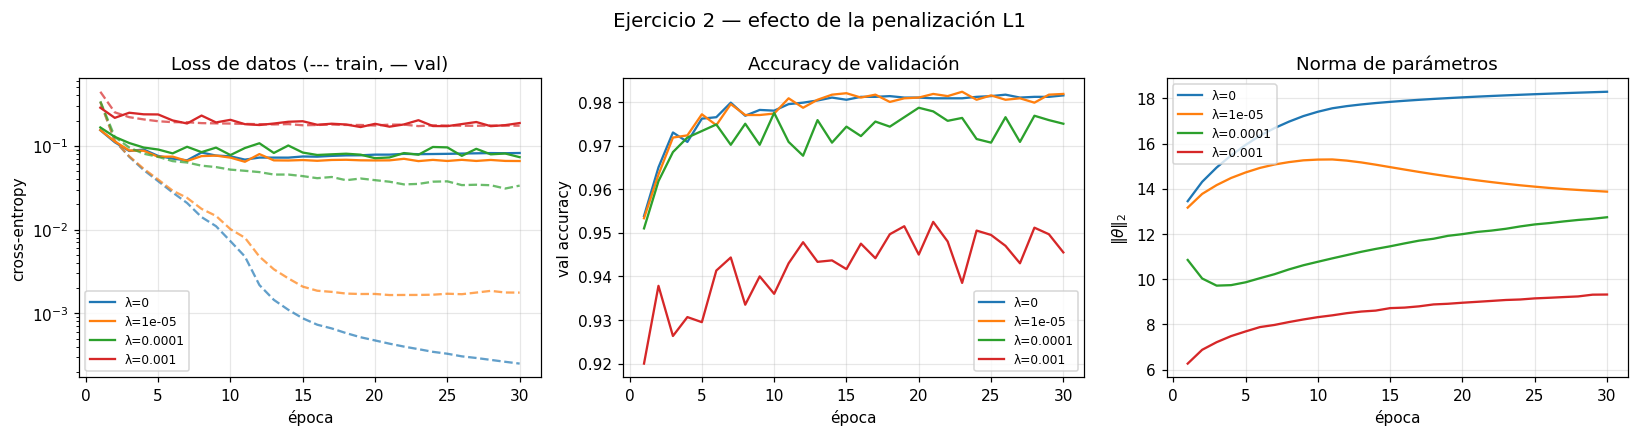

λ (% de pesos con |w| ≤ 1e-3),0.00000,0.00001,0.00010,0.00100
capa,,,,
net.1,2.51,58.07,83.90,95.51
net.3,1.26,29.65,86.02,99.14
net.5,0.55,8.98,49.92,89.22


,λ,capa,n_pesos,% |w|<=1e-3,% ceros exactos,media |w|
0,0.00000,net.1,200704,2.51,0.0,0.02353
1,0.00000,net.3,32768,1.26,0.0,0.04453
2,0.00000,net.5,1280,0.55,0.0,0.15969
3,0.00001,net.1,200704,58.07,0.0,0.00820
4,0.00001,net.3,32768,29.65,0.0,0.02830
5,0.00001,net.5,1280,8.98,0.0,0.16320
6,0.00010,net.1,200704,83.90,0.0,0.00314
7,0.00010,net.3,32768,86.02,0.0,0.00650
8,0.00010,net.5,1280,49.92,0.0,0.10798
9,0.00100,net.1,200704,95.51,0.0,0.00080


In [8]:
# ----------------------------------------------------------------------------
# Curvas train/val para los distintos lambda + sparsity por capa
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, EPOCHS_2 + 1)
lam_colors = dict(zip(LAMBDAS, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))

for lam in LAMBDAS:
    h, c = res2[lam]["hist"], lam_colors[lam]
    axes[0].plot(ep, h["train_loss"], color=c, ls="--", alpha=.7)
    axes[0].plot(ep, h["val_loss"],   color=c, ls="-", label=f"λ={lam:g}")
    axes[1].plot(ep, h["val_acc"],    color=c, ls="-", label=f"λ={lam:g}")
    axes[2].plot(ep, h["param_norm"], color=c, ls="-", label=f"λ={lam:g}")

axes[0].set(xlabel="época", ylabel="cross-entropy", yscale="log",
            title="Loss de datos (--- train, — val)")
axes[1].set(xlabel="época", ylabel="val accuracy", title="Accuracy de validación")
axes[2].set(xlabel="época", ylabel=r"$\|\theta\|_2$", title="Norma de parámetros")
for a in axes:
    a.legend(fontsize=8)
    a.grid(alpha=.3)
fig.suptitle("Ejercicio 2 — efecto de la penalización L1", fontsize=13)
fig.tight_layout()
plt.show()

# Sparsity por capa
rows = []
for lam in LAMBDAS:
    for lname, s in res2[lam]["stats"].items():
        rows.append({"λ": lam, "capa": lname, "n_pesos": s["n"],
                     "% |w|<=1e-3": round(100 * s["casi_cero"], 2),
                     "% ceros exactos": round(100 * s["zeros_exactos"], 2),
                     "media |w|": round(s["mean_abs"], 5)})
sparsity_L1 = pd.DataFrame(rows)
display(sparsity_L1.pivot(index="capa", columns="λ",
                          values="% |w|<=1e-3").round(2)
        .rename_axis(columns="λ  (% de pesos con |w| ≤ 1e-3)"))
display(sparsity_L1)

In [9]:
# ============================================================================
# EJERCICIO 2, parte B — pruning l1_unstructured del baseline (λ=0)
# ============================================================================
PRUNE_AMOUNTS = [0.3, 0.5, 0.8]
FT_EPOCHS, FT_LR = 10, 1e-3

baseline = res2[0.0]["model"]
criterion = nn.CrossEntropyLoss()
_, val_loader_2 = make_loaders(BATCH_2)
base_loss, base_acc = evaluate(baseline, val_loader_2, criterion)
print(f"Baseline (λ=0) val_acc = {base_acc:.4f}\n")


def linear_modules(model):
    return [m for m in model.modules() if isinstance(m, nn.Linear)]


def global_sparsity(model):
    """% de pesos exactamente cero, contando el peso EFECTIVO (post-máscara)."""
    tot, zeros = 0, 0
    for m in linear_modules(model):
        w = m.weight.detach()          # con prune activo, esto ya es weight_orig*mask
        tot += w.numel()
        zeros += int((w == 0).sum().item())
    return zeros / tot


res_prune = {}
for p in PRUNE_AMOUNTS:
    print(f"=== pruning p={p:.0%} ===")
    set_seed(SEED)
    m = copy.deepcopy(baseline)

    # l1_unstructured poda, DENTRO DE CADA CAPA, la fracción p de pesos con
    # menor |w|. Es "unstructured": elimina pesos individuales, no neuronas.
    for lin in linear_modules(m):
        prune.l1_unstructured(lin, name="weight", amount=p)

    _, acc_now = evaluate(m, val_loader_2, criterion)
    sp_now = global_sparsity(m)
    print(f"   inmediato: val_acc={acc_now:.4f} | sparsity={sp_now:.1%}")

    # Fine-tuning: los hooks de prune reaplican la máscara en cada forward,
    # así que los pesos podados permanecen en cero durante todo el fine-tuning.
    tl2, _ = make_loaders(BATCH_2)
    opt = optim.SGD(m.parameters(), lr=FT_LR, momentum=0.9)
    hist_ft = fit(m, tl2, val_loader_2, opt, FT_EPOCHS, tag=f"ft p={p:.0%}", log_every=5)
    acc_ft = hist_ft["val_acc"][-1]
    sp_ft = global_sparsity(m)

    stats_ft = layer_weight_stats(m)
    for lin in linear_modules(m):
        prune.remove(lin, "weight")     # fija la máscara en el tensor `weight`

    res_prune[p] = dict(acc_inmediato=acc_now, sparsity_inmediato=sp_now,
                        acc_finetune=acc_ft, sparsity_finetune=sp_ft,
                        hist=hist_ft, stats=stats_ft,
                        weights=all_weights(m).clone(), model=m)
    print(f"   fine-tune : val_acc={acc_ft:.4f} | sparsity={sp_ft:.1%}\n")

Baseline (λ=0) val_acc = 0.9815

=== pruning p=30% ===
   inmediato: val_acc=0.9808 | sparsity=30.0%


   [ft p=30%] ep   1/10 | train 0.0004/1.0000 | val 0.0805/0.9813 | ||θ||=  18.29


   [ft p=30%] ep   5/10 | train 0.0003/1.0000 | val 0.0807/0.9813 | ||θ||=  18.30


   [ft p=30%] ep  10/10 | train 0.0003/1.0000 | val 0.0810/0.9817 | ||θ||=  18.31
   [ft p=30%] listo en 14.1s
   fine-tune : val_acc=0.9817 | sparsity=30.0%

=== pruning p=50% ===
   inmediato: val_acc=0.9793 | sparsity=50.0%


   [ft p=50%] ep   1/10 | train 0.0012/0.9999 | val 0.0757/0.9800 | ||θ||=  18.30


   [ft p=50%] ep   5/10 | train 0.0008/1.0000 | val 0.0753/0.9793 | ||θ||=  18.32


   [ft p=50%] ep  10/10 | train 0.0007/1.0000 | val 0.0757/0.9790 | ||θ||=  18.34
   [ft p=50%] listo en 13.4s
   fine-tune : val_acc=0.9790 | sparsity=50.0%

=== pruning p=80% ===
   inmediato: val_acc=0.9483 | sparsity=80.0%


   [ft p=80%] ep   1/10 | train 0.0275/0.9945 | val 0.0726/0.9768 | ||θ||=  18.35


   [ft p=80%] ep   5/10 | train 0.0117/0.9992 | val 0.0666/0.9785 | ||θ||=  18.52


   [ft p=80%] ep  10/10 | train 0.0084/0.9997 | val 0.0658/0.9793 | ||θ||=  18.69
   [ft p=80%] listo en 13.7s
   fine-tune : val_acc=0.9793 | sparsity=80.0%



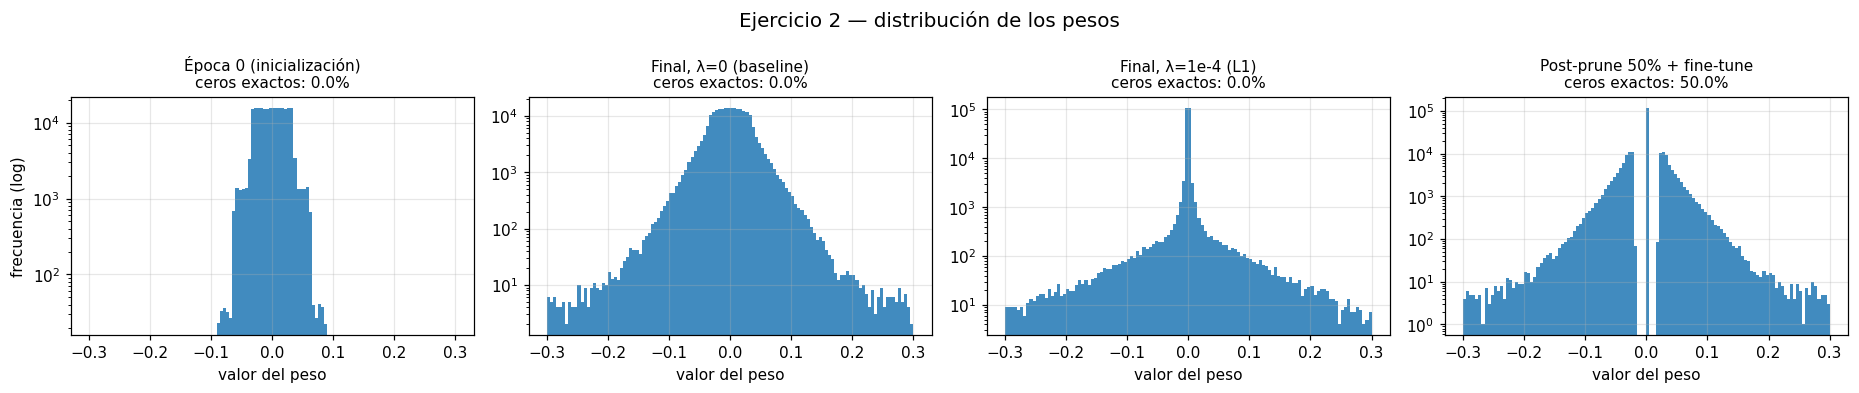

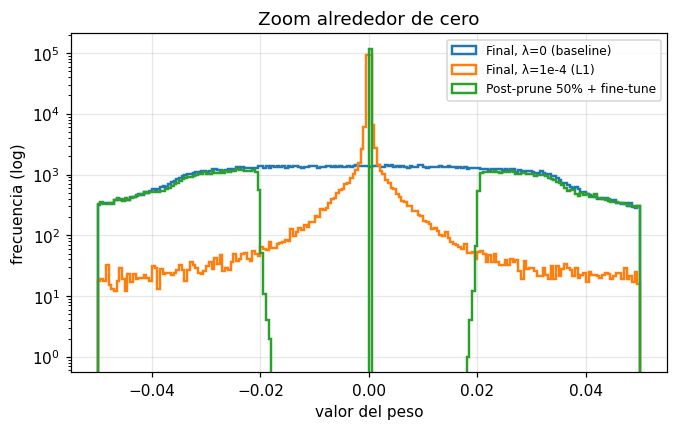

In [10]:
# ----------------------------------------------------------------------------
# Histogramas de pesos: época 0, final (λ=0), final (λ=1e-4) y post-prune 50%
# ----------------------------------------------------------------------------
panels = [
    ("Época 0 (inicialización)", W_INIT),
    ("Final, λ=0 (baseline)",    res2[0.0]["weights"]),
    ("Final, λ=1e-4 (L1)",       res2[1e-4]["weights"]),
    ("Post-prune 50% + fine-tune", res_prune[0.5]["weights"]),
]

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6), sharex=True)
for ax, (title, w) in zip(axes, panels):
    ax.hist(w.numpy(), bins=120, range=(-0.3, 0.3), color="tab:blue", alpha=.85)
    ax.set_yscale("log")
    frac0 = float((w == 0).float().mean())
    ax.set_title(f"{title}\nceros exactos: {frac0:.1%}", fontsize=10)
    ax.set_xlabel("valor del peso")
    ax.grid(alpha=.3)
axes[0].set_ylabel("frecuencia (log)")
fig.suptitle("Ejercicio 2 — distribución de los pesos", fontsize=13)
fig.tight_layout()
plt.show()

# Zoom cerca de cero: es donde se ve la diferencia entre L1 y pruning
fig, ax = plt.subplots(figsize=(7, 4))
for title, w in panels[1:]:
    ax.hist(w.numpy(), bins=200, range=(-0.05, 0.05), histtype="step", lw=1.6, label=title)
ax.set(yscale="log", xlabel="valor del peso", ylabel="frecuencia (log)",
       title="Zoom alrededor de cero")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
plt.show()

In [11]:
# ----------------------------------------------------------------------------
# Tabla resumen: λ / %prune -> accuracy y sparsity
# ----------------------------------------------------------------------------
rows = []
for lam in LAMBDAS:
    r = res2[lam]
    tot = sum(s["n"] for s in r["stats"].values())
    casi = sum(s["casi_cero"] * s["n"] for s in r["stats"].values()) / tot
    exac = sum(s["zeros_exactos"] * s["n"] for s in r["stats"].values()) / tot
    rows.append({"config": f"L1 λ={lam:g}", "tipo": "L1",
                 "train_acc": round(r["train_acc"], 4),
                 "val_acc": round(r["val_acc"], 4),
                 "val_acc post-FT": np.nan,
                 "% ceros exactos": round(100 * exac, 2),
                 "% |w|<=1e-3": round(100 * casi, 2),
                 "||θ||₂": round(r["param_norm"], 2)})

for p in PRUNE_AMOUNTS:
    r = res_prune[p]
    tot = sum(s["n"] for s in r["stats"].values())
    casi = sum(s["casi_cero"] * s["n"] for s in r["stats"].values()) / tot
    rows.append({"config": f"prune {p:.0%} (baseline λ=0)", "tipo": "pruning",
                 "train_acc": np.nan,
                 "val_acc": round(r["acc_inmediato"], 4),
                 "val_acc post-FT": round(r["acc_finetune"], 4),
                 "% ceros exactos": round(100 * r["sparsity_finetune"], 2),
                 "% |w|<=1e-3": round(100 * casi, 2),
                 "||θ||₂": np.nan})

tabla2 = pd.DataFrame(rows)
display(tabla2)

print(f"Baseline sin podar: val_acc = {res2[0.0]['val_acc']:.4f}")
for p in PRUNE_AMOUNTS:
    r = res_prune[p]
    d0 = 100 * (r["acc_inmediato"] - res2[0.0]["val_acc"])
    d1 = 100 * (r["acc_finetune"] - res2[0.0]["val_acc"])
    print(f"  p={p:.0%}: inmediato {r['acc_inmediato']:.4f} ({d0:+.2f} pp) -> "
          f"post fine-tune {r['acc_finetune']:.4f} ({d1:+.2f} pp)")

,config,tipo,train_acc,val_acc,val_acc post-FT,% ceros exactos,% |w|<=1e-3,||θ||₂
0,L1 λ=0,L1,1.0000,0.9815,NaN,0.0,2.33,18.29
1,L1 λ=1e-05,L1,1.0000,0.9818,NaN,0.0,53.84,13.87
2,L1 λ=0.0001,L1,0.9892,0.9750,NaN,0.0,84.01,12.74
3,L1 λ=0.001,L1,0.9478,0.9455,NaN,0.0,95.98,9.32
4,prune 30% (baseline λ=0),pruning,NaN,0.9808,0.9817,30.0,30.00,NaN
5,prune 50% (baseline λ=0),pruning,NaN,0.9793,0.9790,50.0,50.00,NaN
6,prune 80% (baseline λ=0),pruning,NaN,0.9483,0.9793,80.0,80.00,NaN


Baseline sin podar: val_acc = 0.9815
  p=30%: inmediato 0.9808 (-0.07 pp) -> post fine-tune 0.9817 (+0.02 pp)
  p=50%: inmediato 0.9793 (-0.22 pp) -> post fine-tune 0.9790 (-0.25 pp)
  p=80%: inmediato 0.9483 (-3.32 pp) -> post fine-tune 0.9793 (-0.22 pp)


**Interpretación:**

**a) L1 produce sparsity real, pero no ceros exactos.** La columna `% ceros exactos` es `0.00` en las cuatro corridas de L1: descenso de gradiente con paso finito nunca aterriza *exactamente* en cero, solo se acerca mucho. Lo que sí cambia dramáticamente es la masa cerca de cero: `2.33% → 53.84% → 84.01% → 95.98%` de los pesos con `|w| ≤ 1e-3` para `λ = 0 / 1e-5 / 1e-4 / 1e-3`, y `‖θ‖₂` baja de `18.29` a `9.32`. Los histogramas lo muestran: la inicialización es casi uniforme en `±1/√fan_in`, el baseline final se ensancha, y con L1 la distribución colapsa en un pico agudo en cero con colas largas — la firma de la penalización L1, que empuja *todos* los pesos hacia cero a velocidad constante (`λ·sign(w)`) y solo sobreviven aquellos cuyo gradiente de datos supera ese empuje.

**b) El trade-off sparsity ↔ desempeño no es lineal: hay un tramo gratis y luego un despeñadero.**

| λ | % pesos con `\|w\| ≤ 1e-3` | val_acc | vs baseline |
|---|---|---|---|
| 0 | 2.33% | 0.9815 | — |
| 1e-5 | 53.84% | 0.9818 | **+0.03 pp** |
| 1e-4 | 84.01% | 0.9750 | −0.65 pp |
| 1e-3 | 95.98% | 0.9455 | −3.60 pp |

Con `λ=1e-5` obtenemos **más de la mitad de los pesos en ≈0 gratis** (de hecho la val_acc sube marginalmente). Con `λ=1e-3` el modelo ya no sobreajusta — *subajusta*: `train_acc = 0.9478` es casi igual a `val_acc = 0.9455`, o sea la penalización domina al término de datos y la red ya no tiene capacidad efectiva para memorizar ni siquiera el train.

**c) L1 no sparsifica todas las capas igual.** Con `λ=1e-5`: `58.07%` en `net.1` (784→256, 200 704 pesos), `29.65%` en `net.3` (256→128) y solo `8.98%` en `net.5` (128→10, 1 280 pesos). Tiene sentido por dos motivos que se suman: (i) la primera capa mira píxeles del borde que están casi siempre en cero, así que hay muchísimos pesos cuyo gradiente de datos es prácticamente nulo y que la L1 apaga sin resistencia; (ii) la capa de salida tiene 157× menos parámetros, cada uno carga mucha más responsabilidad (su `media |w|` baseline es `0.1597` vs `0.0235` en la primera capa) y por eso resiste el empuje mucho más. Moraleja práctica: un `λ` global aplica una presión muy desigual según el tamaño y el papel de cada capa.

**d) El pruning es sorprendentemente barato — y sí, el fine-tuning recupera.**

| p | val_acc inmediato | Δ | val_acc post fine-tune (10 ép., lr=1e-3) | Δ |
|---|---|---|---|---|
| 30% | 0.9808 | −0.07 pp | 0.9817 | **+0.02 pp** |
| 50% | 0.9793 | −0.22 pp | 0.9790 | −0.25 pp |
| 80% | 0.9483 | **−3.32 pp** | 0.9793 | **−0.22 pp** |

Hasta el **50% la poda es esencialmente gratis sin hacer nada** (`−0.22 pp`, dentro del ruido de una sola semilla), lo que dice que más de la mitad de los 234 752 pesos de esta red son redundantes para MNIST. Al 80% sí duele de golpe (`−3.32 pp`), pero **10 épocas de fine-tuning recuperan 3.1 de esos 3.32 pp**. La lectura correcta es: quitar el 80% de los pesos más pequeños no destruye la capacidad de la red, solo la **descoloca del punto de operación**; los pesos que quedan solo necesitan reajustarse. Nota de implementación: los hooks de `prune` reaplican la máscara en cada forward, así que la sparsity se mantiene exactamente en `80.0%` durante todo el fine-tuning — no estamos "des-podando" por la puerta de atrás.

**e) ¿L1 o pruning?** A sparsity comparable, **pruning + fine-tune gana**: `λ=1e-4` da 84% de pesos ≈0 con `val_acc = 0.9750`, mientras que podar 80% y afinar da 80% de ceros **exactos** con `val_acc = 0.9793` (+0.43 pp). Y los ceros del pruning son ceros de verdad, que sí se pueden explotar con formatos dispersos; los de L1 hay que umbralizar a mano (con el riesgo de tirar pesos que importaban). La ventaja de L1 es de proceso: no hay que elegir `p`, no hay una segunda fase, y la sparsity emerge del mismo entrenamiento — útil cuando lo que quieres no es comprimir sino **seleccionar variables** (qué entradas usa el modelo), que es un caso frecuente en política pública.

### Ejercicio 3: Data augmentation en régimen de pocos datos

**Setup.** MNIST reducido a `N_train = 2000` ejemplos (los primeros 2000 del split de entrenamiento permutado, es decir una muestra aleatoria fija), la **misma red del ejercicio 1** (`784 → 512 → 10`), `epochs=40`, `batch_size=64`, `lr=1e-2` con SGD + momentum(0.9). La validación son los **6000** ejemplos del split de validación, siempre **sin** augmentation.

**Las tres condiciones.**

| condición | transformación aplicada al train |
|---|---|
| `baseline` | `ToTensor` + `Normalize` |
| `augment` | `RandomAffine(degrees=10, translate=(2/28, 2/28), scale=(0.95, 1.05))` + `ToTensor` + `Normalize` |
| `gauss-noise` | `ToTensor` + `Normalize` + ruido gaussiano `σ=0.5` en unidades normalizadas |

Notas de diseño:
- `translate=(2/28, 2/28)` es la forma de pedirle a `RandomAffine` traslaciones de **±2 píxeles** (el argumento es una fracción del ancho/alto de la imagen).
- Los augmentations son deliberadamente **conservadores**: rotaciones grandes o volteos horizontales cambiarían la etiqueta (un 6 volteado no es un 6), así que romperían la invarianza que sí queremos imponer.
- `σ=0.5` en unidades normalizadas equivale a ≈ `0.5 × 0.3081 ≈ 0.15` en escala de píxel [0,1]: ruido visible pero que no destruye el dígito.
- El ruido y el affine se muestrean **de nuevo en cada época**, así que el modelo nunca ve dos veces exactamente el mismo ejemplo.
- `train_acc` de la tabla se mide siempre sobre los 2000 ejemplos **limpios** (sin augmentation); si no, el `gap` no sería comparable entre condiciones.

In [12]:
# ============================================================================
# EJERCICIO 3 — pocos datos: baseline vs augmentation vs ruido gaussiano
# ============================================================================
N_TRAIN, EPOCHS_3, BATCH_3, LR_3 = 2000, 40, 64, 1e-2
NOISE_STD = 0.5          # en unidades normalizadas (~0.15 en escala de píxel)


class AddGaussianNoise:
    """Ruido gaussiano aditivo sobre el tensor YA normalizado.

    Se aplica dentro del pipeline de transforms, o sea que se vuelve a muestrear
    en cada acceso al dataset -> cada época ve una realización distinta del ruido.
    """

    def __init__(self, std=0.5):
        self.std = std

    def __call__(self, x):
        return x + torch.randn_like(x) * self.std

    def __repr__(self):
        return f"AddGaussianNoise(std={self.std})"


normalize = transforms.Normalize((MEAN,), (STD,))
TFMS = {
    "baseline": transforms.Compose([transforms.ToTensor(), normalize]),
    "augment": transforms.Compose([
        transforms.RandomAffine(degrees=10,
                                translate=(2 / 28, 2 / 28),   # ±2 píxeles
                                scale=(0.95, 1.05)),
        transforms.ToTensor(), normalize]),
    "gauss-noise": transforms.Compose([transforms.ToTensor(), normalize,
                                       AddGaussianNoise(NOISE_STD)]),
}

# Índices: los mismos 2000 de entrenamiento y los mismos 6000 de validación
idx_small = IDX_TRAIN[:N_TRAIN].tolist()
idx_val_l = IDX_VAL.tolist()

clean_tfm = TFMS["baseline"]
val_ds_3 = Subset(datasets.MNIST(DATA_ROOT, train=True, download=True,
                                 transform=clean_tfm), idx_val_l)
train_clean_3 = Subset(datasets.MNIST(DATA_ROOT, train=True, download=True,
                                      transform=clean_tfm), idx_small)
val_loader_3 = DataLoader(val_ds_3, batch_size=1024, shuffle=False)
train_clean_loader = DataLoader(train_clean_3, batch_size=1024, shuffle=False)
print(f"N_train={len(train_clean_3)} | N_val={len(val_ds_3)}")

res3 = {}
for cond, tfm in TFMS.items():
    print(f"\n=== {cond} ===")
    set_seed(SEED)
    ds_c = Subset(datasets.MNIST(DATA_ROOT, train=True, download=True, transform=tfm),
                  idx_small)
    g = torch.Generator().manual_seed(SEED)
    tl = DataLoader(ds_c, batch_size=BATCH_3, shuffle=True, generator=g)

    model = MLP(hidden=(512,)).to(device)
    opt = optim.SGD(model.parameters(), lr=LR_3, momentum=0.9)
    hist = fit(model, tl, val_loader_3, opt, EPOCHS_3, tag=cond)

    crit = nn.CrossEntropyLoss()
    tr_loss_clean, tr_acc_clean = evaluate(model, train_clean_loader, crit)
    va_loss, va_acc = evaluate(model, val_loader_3, crit)

    res3[cond] = dict(hist=hist, model=model,
                      train_acc_clean=tr_acc_clean, train_loss_clean=tr_loss_clean,
                      val_acc=va_acc, val_loss=va_loss,
                      param_norm=hist["param_norm"][-1],
                      ece=expected_calibration_error(model, val_loader_3, 15))
    print(f"   train_acc(limpio)={tr_acc_clean:.4f} | val_acc={va_acc:.4f} "
          f"| gap={tr_acc_clean - va_acc:+.4f}")

N_train=2000 | N_val=6000

=== baseline ===


   [baseline] ep   1/40 | train 1.2526/0.6585 | val 0.5490/0.8363 | ||θ||=  13.44


   [baseline] ep  10/40 | train 0.0771/0.9860 | val 0.3111/0.9150 | ||θ||=  14.12


   [baseline] ep  20/40 | train 0.0190/1.0000 | val 0.3149/0.9198 | ||θ||=  14.53


   [baseline] ep  30/40 | train 0.0096/1.0000 | val 0.3295/0.9193 | ||θ||=  14.74


...

   [gauss-noise] ep  10/40 | train 0.1161/0.9705 | val 0.2990/0.9167 | ||θ||=  14.13


   [gauss-noise] ep  20/40 | train 0.0324/0.9985 | val 0.2955/0.9228 | ||θ||=  14.58


   [gauss-noise] ep  30/40 | train 0.0198/0.9990 | val 0.3008/0.9275 | ||θ||=  14.86


   [gauss-noise] ep  40/40 | train 0.0115/1.0000 | val 0.3082/0.9282 | ||θ||=  15.03
   [gauss-noise] listo en 13.4s


   train_acc(limpio)=1.0000 | val_acc=0.9282 | gap=+0.0718


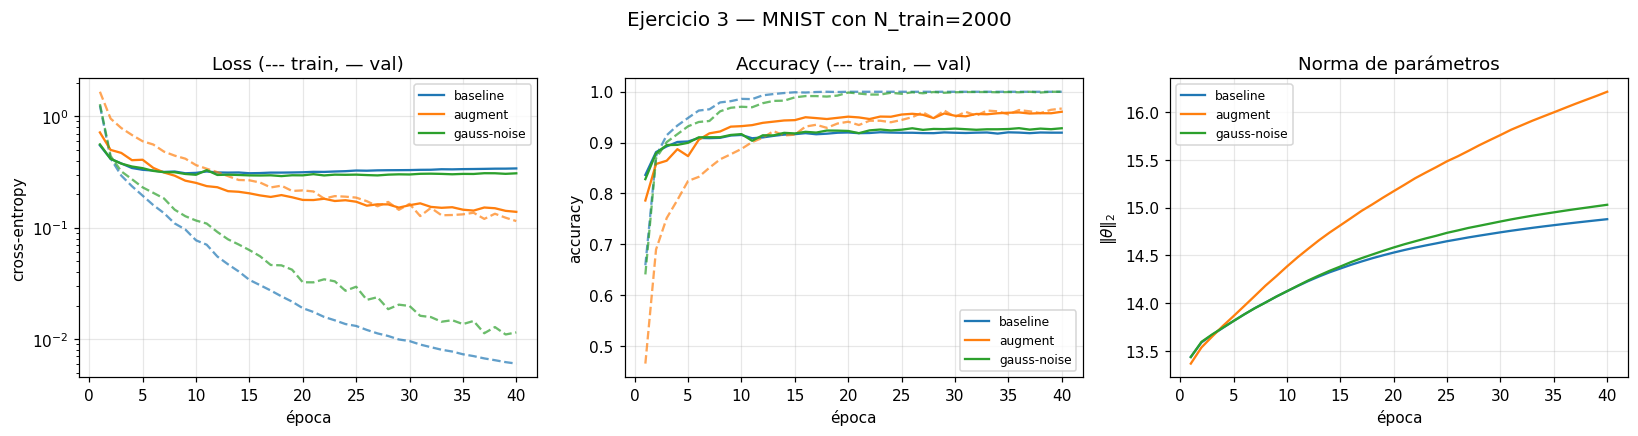

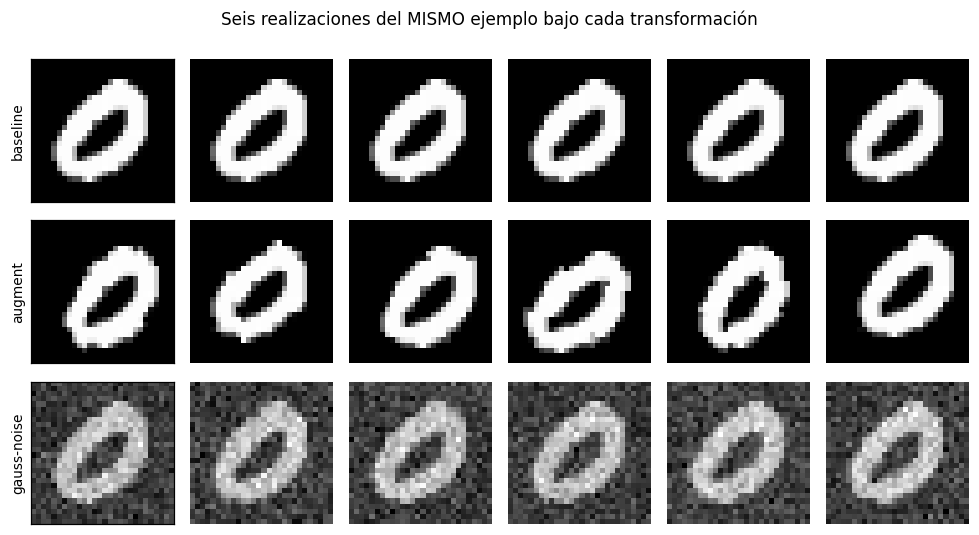

In [13]:
# ----------------------------------------------------------------------------
# Curvas comparativas y ejemplos visuales de las transformaciones
# ----------------------------------------------------------------------------
cond_colors = {"baseline": "tab:blue", "augment": "tab:orange", "gauss-noise": "tab:green"}
ep = range(1, EPOCHS_3 + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for cond in TFMS:
    h, c = res3[cond]["hist"], cond_colors[cond]
    axes[0].plot(ep, h["train_loss"], color=c, ls="--", alpha=.7)
    axes[0].plot(ep, h["val_loss"],   color=c, ls="-", label=cond)
    axes[1].plot(ep, h["train_acc"],  color=c, ls="--", alpha=.7)
    axes[1].plot(ep, h["val_acc"],    color=c, ls="-", label=cond)
    axes[2].plot(ep, h["param_norm"], color=c, ls="-", label=cond)

axes[0].set(xlabel="época", ylabel="cross-entropy", yscale="log",
            title="Loss (--- train, — val)")
axes[1].set(xlabel="época", ylabel="accuracy", title="Accuracy (--- train, — val)")
axes[2].set(xlabel="época", ylabel=r"$\|\theta\|_2$", title="Norma de parámetros")
for a in axes:
    a.legend(fontsize=8)
    a.grid(alpha=.3)
fig.suptitle(f"Ejercicio 3 — MNIST con N_train={N_TRAIN}", fontsize=13)
fig.tight_layout()
plt.show()

# Cómo se ve cada transformación sobre el mismo dígito
fig, axes = plt.subplots(3, 6, figsize=(9, 5))
for row, cond in enumerate(TFMS):
    ds_show = Subset(datasets.MNIST(DATA_ROOT, train=True, transform=TFMS[cond]), idx_small)
    for col in range(6):
        img, lab = ds_show[0]
        axes[row, col].imshow(img.squeeze().numpy(), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].axis("on")
    axes[row, 0].set(xticks=[], yticks=[])
    axes[row, 0].set_ylabel(cond, fontsize=9)
fig.suptitle("Seis realizaciones del MISMO ejemplo bajo cada transformación", fontsize=11)
fig.tight_layout()
plt.show()

In [14]:
# ----------------------------------------------------------------------------
# Tabla resumen del ejercicio 3
# ----------------------------------------------------------------------------
rows = []
for cond in TFMS:
    r = res3[cond]
    rows.append({
        "condición": cond,
        "train_acc": round(r["train_acc_clean"], 4),
        "val_acc": round(r["val_acc"], 4),
        "gap = train − val": round(r["train_acc_clean"] - r["val_acc"], 4),
        "val_loss": round(r["val_loss"], 4),
        "param_norm": round(r["param_norm"], 2),
        "ECE(15 bins)": round(r["ece"], 4),
    })
tabla3 = pd.DataFrame(rows)
display(tabla3)

base = res3["baseline"]["val_acc"]
for cond in TFMS:
    if cond != "baseline":
        print(f"{cond}: val_acc {res3[cond]['val_acc']:.4f} "
              f"({100 * (res3[cond]['val_acc'] - base):+.2f} pp vs baseline)")

,condición,train_acc,val_acc,gap = train − val,val_loss,param_norm,ECE(15 bins)
0,baseline,1.000,0.9195,0.0805,0.3409,14.88,0.0350
1,augment,0.994,0.9607,0.0333,0.1389,16.21,0.0124
2,gauss-noise,1.000,0.9282,0.0718,0.3082,15.03,0.0313


augment: val_acc 0.9607 (+4.12 pp vs baseline)
gauss-noise: val_acc 0.9282 (+0.87 pp vs baseline)


**Interpretación:**

**a) Con 2000 ejemplos, el baseline memoriza y punto.** `train_acc = 1.0000` contra `val_acc = 0.9195`: un gap de `8.05 pp`. La curva de `train_loss` cae hasta `0.0060` mientras la `val_loss` **sube** después de las primeras épocas hasta `0.3409`. La red tiene 407 050 parámetros para 2000 ejemplos — 200 parámetros por ejemplo — así que memorizar es trivial. El ECE de `0.0350` confirma el diagnóstico: no solo se equivoca más, se equivoca con confianza injustificada.

**b) La augmentation geométrica es la que claramente mejor compensa los pocos datos.**

| condición | train_acc | val_acc | gap | val_loss | ‖θ‖₂ | ECE |
|---|---|---|---|---|---|---|
| baseline | 1.0000 | 0.9195 | 0.0805 | 0.3409 | 14.88 | 0.0350 |
| **augment** | 0.9940 | **0.9607** | **0.0333** | **0.1389** | 16.21 | **0.0124** |
| gauss-noise | 1.0000 | 0.9282 | 0.0718 | 0.3082 | 15.03 | 0.0313 |

`RandomAffine` da **+4.12 pp de val_acc**, corta el gap a menos de la mitad (`0.0805 → 0.0333`), reduce la `val_loss` un **59%** y el ECE un **65%**. El ruido gaussiano da apenas `+0.87 pp` y prácticamente no toca el gap (`0.0718`) ni el ECE (`0.0313`).

**c) ¿Por qué gana la augmentation geométrica y casi no ayuda el ruido?** Porque no inyectan la misma información:

- `RandomAffine` genera ejemplos que **están en la variedad de los datos reales**: un 3 rotado 8°, desplazado 2 píxeles y escalado 3% es un 3 que una persona efectivamente escribiría. Lo que le estamos enseñando al modelo es una **invarianza correcta y específica del dominio** (la identidad del dígito no depende de su pose exacta). Eso equivale a multiplicar el tamaño efectivo del dataset por el volumen del grupo de transformaciones — sin recolectar un solo dato nuevo.
- El ruido gaussiano i.i.d. por píxel **no está en la variedad**: ninguna imagen real de MNIST se ve así. Lo único que hace es suavizar la función aprendida localmente alrededor de cada punto de entrenamiento (a primer orden es aproximadamente una penalización sobre el jacobiano de la red respecto a la entrada, tipo Tikhonov). Eso ayuda un poco, pero no genera **diversidad de pose**, que es justamente lo que le falta a un conjunto de 2000 ejemplos.

Se ve también en las curvas: baseline y `gauss-noise` bajan la `train_loss` hasta `0.0060` y `0.0115` mientras la validación se estanca; `augment` se queda en `train_loss = 0.1148` con `val_loss = 0.1389` — **prácticamente sin brecha, y la curva de validación todavía va bajando en la época 40**, o sea que con más épocas seguiría mejorando. Con augmentation el modelo nunca ve dos veces exactamente el mismo ejemplo, así que "memorizar el train" deja de ser una estrategia disponible.

**d) Un detalle que conviene notar: `‖θ‖₂` NO baja con augmentation — sube** (`16.21`, la más alta de las tres, contra `14.88` del baseline). Es un buen recordatorio de que *regularizar no es lo mismo que encoger los pesos*. Weight decay y L1 (ejercicios 1 y 2) regularizan restringiendo la **magnitud** de los parámetros; la augmentation regulariza restringiendo la **clase de funciones** admisibles — le exige a la red que sea invariante a un grupo de transformaciones. Puede necesitar pesos *más* grandes para satisfacer esa restricción. Por eso `‖θ‖₂` es un diagnóstico útil de sobreajuste-por-crecimiento-de-norma, pero no es un indicador universal de "cuán regularizado" está un modelo.

**e) Conclusión práctica.** Cuando hay pocos datos, la palanca más rentable es la que codifica una invarianza que **de verdad se cumple en el dominio**. En imágenes de dígitos esa invarianza es geométrica y es fácil de escribir. En un problema de política pública el análogo no es rotar nada: es preguntarse qué transformaciones de los datos dejan la etiqueta intacta (¿reordenar registros?, ¿perturbar una variable dentro de su error de medición?, ¿re-muestrear dentro de un conglomerado?) y usar *esas*. Un augmentation genérico como el ruido gaussiano casi siempre rinde menos que uno que sabe algo del problema.